# Numerical Methods

## Numerical Linear Algebra III

## Learning objectives:

* Consider direct vs indirect (or iterative) methods


* Example iterative algorithm: the *Jacobi* and *Gauss-Seidel* methods


### Roundoff errors

Note that in this course we have largely ignored the limitations of the floating point arithmetic performed by computers, including round-off errors.  

This is often the topic of the first lecture of courses, or first chapter of books, on Numerical Methods or Numerical Analysis - do take a look at some examples if you are interested.  

Also take a look at *D. Goldberg 1991: What every computer scientist should know about floating-point arithmetic, ACM Computing Surveys 23, Pages 5-48*.

For some examples of catastrophic failures due to round off errors see <https://www.ma.utexas.edu/users/arbogast/misc/disasters.html> and <http://ta.twi.tudelft.nl/users/vuik/wi211/disasters.html> and [the sinking of the Sleipner A offshore platform](http://www.ima.umn.edu/~arnold/disasters/sleipner.html).

<br>

As an example, consider the mathematical formula

$$f(x)=(1-x)^{10}.$$

We can of course relatively easily expand this out by hand

$$f(x)=1- 10x + 45x^2 - 120x^3 + 210x^4 - 252x^5 + 210x^6 - 120x^7 + 45x^8 - 10x^9 + x^{10}.$$

Mathematically these two expressions for $f(x)$ are identical; when evaluated by a computer different operations will be performed, which (we hope) should give the same answer. For numbers $x$ away from $1$ these two expressions do return (pretty much) the same answer.  

However, for $x$ close to 1 the second expression adds and subtracts individual terms of increasing size which should largely cancel out, but they don't to sufficient accuracy due to round off errors; these errors accumulate with more and more operations, leading a loss of significance <https://en.wikipedia.org/wiki/Loss_of_significance>

In [16]:
def f1(x):
    return (1. - x)**10

def f2(x):
    return (1. - 10.*x + 45.*x**2 - 120.*x**3 +
           210.*x**4 - 252.*x**5 + 210.*x**6 -
           120.*x**7 + 45.*x**8 - 10.*x**9 + x**10)

# for a value of x away from 1
x=0.6
print(f1(x), f2(x), 1.-f1(x)/f2(x), '\n') # print values computed in different ways and their relative difference
# the error is far down the significant figures

# things get a bit worse as x gets closer to 1
x=0.8
print(f1(x), f2(x), 1.-f1(x)/f2(x), '\n') 

# and a significant error (21%) can be see for a number close to 1
x=0.95
print(f1(x), f2(x), 1.-f1(x)/f2(x)) 
# f2 is simply swamped with round off errors

0.00010485760000000006 0.00010485760000436464 4.1623815505431594e-11 

1.0239999999999978e-07 1.0240001356576212e-07 1.3247813024364063e-07 

9.765625000000086e-14 1.2378986724570495e-13 0.21111273343425307


### Algorithm stability

The susceptibility for a numerical algorithm to dampen (inevitable) errors, rather than to magnify them as we have seen in examples above, is termed *stability*.  This is a concern for numerical linear algebra as considered here, as well as for the numerical solution of differential equations.  In that case you don't want small errors to grow and accumulate as you propagate the solution to an ODE or PDE forward in time say.

If your algorithm is not inherently stable, or has other limitation, you need to understand and appreciate this, as it can cause catastrophic failures! 


## Direct vs indirect/iterative methods

Two types/families of methods exist to solve matrix systems.  These are termed *direct* methods and *iterative* (or *indirect*) methods.

Direct methods perform operations on the linear equations (the matrix system), e.g. the substitution of one equation into another which we performed two weeks ago for your example $2\times 2$ system considered in MM1. This (and the subsequent Gaussian elimination algorithm) transformed the equations making up the linear system into equivalent ones with the aim of eliminating unknowns from some of the equations and hence allowing for easy solution through back (or forward) substitution.

Also, in MM1 you (may have) learnt *Cramer's rule* which gives an explicit formula for the inverse of a matrix, or for the solution of a linear matrix system.  

The computational cost (in terms of arithmetic operations required; also termed complexity) of Cramer's rule scales like $(n+1)!$, whereas the Gaussian elimination method (which is basically the substitution method descrined above, and implemented over the previous two lectures) scales like $n^3$.  $n$ here refers to the number of unknowns or equations, or sometimes termed the *degrees of freedom* of the problem.

For large $n$ Gaussian elimination will clearly be far more efficient. 

<br>




An advantage of direct methods such as Cramer's rule or Gaussian elimination is that they provide the exact solution (assuming exact arithmetic, i.e. ignoring the round off related issues mentioned above) in a finite number of operations, the number of which are known in advance.

However, as pointed out previously, $n$ could be billions for hard-core applications such as in numerical weather forecasting. In this case the $n^3$ operations required of a direct algorithm such as Gaussian elimination is completely prohibitive. In an attempt to further reduce this cost *iterative/indirect* algorithms were devised.

Text(0, 0.5, 'log10(number of operations)')

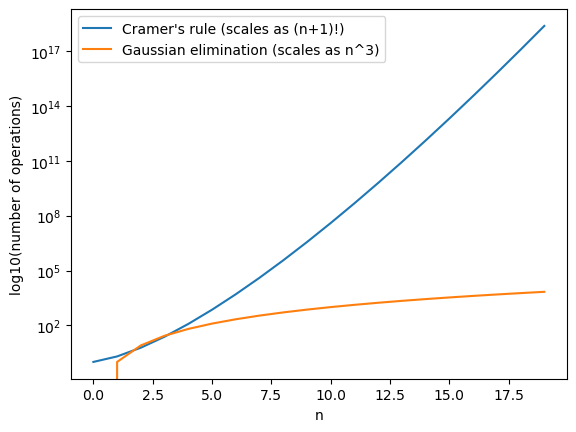

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial

n = np.arange(0,20,1)
plt.plot(n, factorial(n+1), label='Cramer\'s rule (scales as (n+1)!)')
plt.plot(n, n**3, label='Gaussian elimination (scales as n^3)')
plt.yscale('log')
plt.legend()
plt.xlabel('n')
plt.ylabel('log10(number of operations)')

In [18]:
n = np.array([1,2,3,10,100])
print(factorial(n+1))

[2.00000000e+000 6.00000000e+000 2.40000000e+001 3.99168000e+007
 9.42594776e+159]



Iterative or indirect algorithms start with an initial guess at the solution ($\boldsymbol{x}_0$), and *iteratively* improve this producing a series of approximate answers $\boldsymbol{x}_k$. 

For the *exact* answer to the matrix system 

$$A\boldsymbol{x} = \boldsymbol{b}$$ 

we know that the residual vector 

$$\boldsymbol{r} := A\boldsymbol{x}-\boldsymbol{b}$$ 

is zero. 

For our iterative procedure, we can use the norm of the residual vector 

$$\boldsymbol{r}_k := A\boldsymbol{x}_k-\boldsymbol{b}$$ 

based on the approximate solution $\boldsymbol{x}_k$, as a measure of how close we are to solving the equation (the norm $\|\boldsymbol{r}_k\|$ expresses this as a single number). 

As we iterate further, we hope to drive down this number and we may stop the iterations at some small (non-zero) residual norm tolerance level - we never expect to hit a residual of zero exactly. 

The final iteration gives us an answer $\boldsymbol{x}_k$ which is still an approximation to the solution and not the exact (subject to round off errors!) solution we would obtain with direct methods.  The residual norm tolerance stopping criteria therefore needs to be thought about carefully, e.g. depending on how accurate a solution $\boldsymbol{x}$ we require.

We have already considered Gaussian elimination (and back substitution) as examples of direct solution methods. We'll consider an example of an iterative method now.

## Iterative methods - Jacobi's method

Consider our matrix system

$$A\boldsymbol{x}=\boldsymbol{b} \quad \iff \quad \sum_{j=1}^nA_{ij}x_j=b_i,\quad \textrm{for}\quad i=1,2,\ldots, n.$$

Let's rewrite this by pulling out the term involving $x_i$ (i.e. for each row $i$ pull out the diagonal from the summation):

$$A_{ii}x_i + \sum_{\substack{j=1\\ j\ne i}}^nA_{ij}x_j=b_i,\quad  i=1,2,\ldots, n.$$

We can then rearrange to come up with a formula for our unknown $x_i$:

$$x_i = \frac{1}{A_{ii}}\left(b_i- \sum_{\substack{j=1\\ j\ne i}}^nA_{ij}x_j\right),\quad  i=1,2,\ldots, n.$$

<br><br>

Now of course for each individual $x_i$, all the other components of $\boldsymbol{x}$ appearing on the RHS are also unknown and so this is an example of an implicit formula which doesn't help us directly, but does suggest the following iterative scheme:


* Starting from a guess at the solution $\boldsymbol{x}^{(0)}$



* iterate for $k>0$
$$x_i^{(k)} = \frac{1}{A_{ii}}\left(b_i- \sum_{\substack{j=1\\ j\ne i}}^nA_{ij}x_j^{(k-1)}\right),\quad  i=1,2,\ldots, n.$$


Note that for this iteration, for a fixed $k$, it does not matter in which order we perform the operations over $i$ as the right hand side only contains the entries of $\boldsymbol{x}$ at the previous iteration [based on this system can you think of a possible way to improve this algorithm?]

Let's implement and test this algorithm:

[5.         1.14285714]
[ 4.92857143 -1.71428571]
[ 6.35714286 -1.66326531]
[ 6.33163265 -2.68367347]
[ 6.84183673 -2.6654519 ]
[ 6.83272595 -3.02988338]
[ 7.01494169 -3.02337568]
[ 7.01168784 -3.15352978]
[ 7.07676489 -3.1512056 ]
[ 7.0756028  -3.19768921]
[ 7.0988446  -3.19685914]
[ 7.09842957 -3.21346043]
[ 7.10673022 -3.21316398]
[ 7.10658199 -3.21909301]
[ 7.10954651 -3.21898714]
[ 7.10949357 -3.22110465]
[ 7.11055232 -3.22106683]
[ 7.11053342 -3.22182309]
[ 7.11091154 -3.22180958]
[ 7.11090479 -3.22207967]
[ 7.11103984 -3.22207485]
[ 7.11103743 -3.22217131]
[ 7.11108566 -3.22216959]
[ 7.11108479 -3.22220404]
[ 7.11110202 -3.22220342]
[ 7.11110171 -3.22221573]
[ 7.11110786 -3.22221551]
[ 7.11110775 -3.2222199 ]
[ 7.11110995 -3.22221982]
[ 7.11110991 -3.22222139]
[ 7.1111107  -3.22222137]
[ 7.11111068 -3.22222193]
[ 7.11111096 -3.22222192]
[ 7.11111096 -3.22222212]
[ 7.11111106 -3.22222211]
[ 7.11111106 -3.22222218]
[ 7.11111109 -3.22222218]
[ 7.11111109 -3.22222221]
[ 7.1111111  -

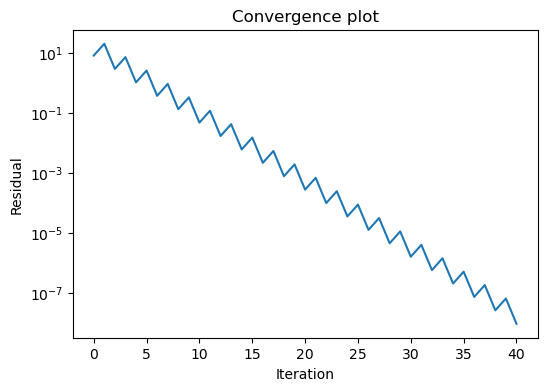

Total number of iterations:  40
[ 7.11111111 -3.22222222]
[ 7.11111111 -3.22222222]


In [ ]:
import scipy.linalg as sl
A = np.array([[10., 2., 3., 5.],[1., 14., 6., 2.],[-1., 4., 16., -4],[5. ,4. ,3. ,11. ]])
b = np.array([1., 2., 3., 4.])
A = np.array([[2,1],[5,7]])
b = np.array([11,13])

# an initial guess at the solution - here just a vector of zeros of length the number of rows in A
x = np.zeros(A.shape[0]) 
x = np.ones(A.shape[0])

# specify an iteration tolerance - our stopping criteria
tol = 1.e-6

# specify an upper limit on the number of iterations - if we don't hit tolerance
# then stop the algorithm, so that it doesn't go on for ever potentially
it_max = 1000

# for later plotting let's start a list to store the residuals
residuals=[] 

# now iterate
for it in range(it_max):
    x_new = np.zeros(A.shape[0])  # initialise the new solution vector
    for i in range(A.shape[0]):
        x_new[i] = (1./A[i, i]) * (b[i] 
                                   - (np.dot(A[i, :i], x[:i]) 
                                   + np.dot(A[i, i+1:], x[i+1:])))

    residual = sl.norm(A @ x - b)  # calculate the norm of the residual r=Ax-b for this latest guess
    residuals.append(residual) # store it for later plotting
    if (residual < tol): # if less than our required tolerance jump out of the iteration and end.
        break
    print(x_new)
    x = x_new # update old solution

# plot the log of the residual against iteration number 
fig = plt.figure(figsize=(6, 4))
ax1 = plt.subplot(111)
ax1.semilogy(residuals) # plot the log of the residual against iteration number 
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Residual')
ax1.set_title('Convergence plot')
plt.show()

# print out the number of iterations, 
# if this is it_max we know the algorithm didn't actually converge
print('Total number of iterations: ', it)

print(x_new) # our solution vector
print(sl.inv(A) @ b)  # check against scipy

## Iterative methods - Gauss-Seidel's method

We can make a small improvement to Jacobi's method using the updated components of the solution vector as soon as they become available (rather than only using them in the following iteration):


* Starting from a guess at the solution $\boldsymbol{x}^{(0)}$



* iterate for $k>0$
$$x_i^{(k)} = \frac{1}{A_{ii}}\left(b_i- \sum_{\substack{j=1\\ j< i}}^nA_{ij}x_j^{(k)} - \sum_{\substack{j=1\\ j> i}}^nA_{ij}x_j^{(k-1)}\right),\quad  i=1,2,\ldots, n.$$


Note that as opposed to Jacobi, we can overwrite the entries of $\boldsymbol{x}$ as they are updated, with Jacobi we need to store both the new as well as the old iteration (i.e. not overwrite the old entries until we have finished with them - which was not until the end of every iteration).

As we are using updated knowledge immediately, the Gauss-Seidel algorithm we hope that we should converge faster than Jacobi 

[but note that this convergence can only be *guaranteed* for matrices which are diagonally dominant - that is for every row, the magnitude of value on the main diagonal is greater than the sum of the magnitudes of all the other entries in that row - or if the matrix is *symmetric positive definite* (a property we won't define in this module].  



### <span style="color:blue">Exercise 3: Implement Gauss-Seidel's method.</span>

Generalise the Jacobi code to solve the matrix problem using Gauss-Seidel's method.